In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [2]:
# Load processed data
df = pd.read_csv("../../data/processed/urls_processed.csv")

# only keep features and label for modeling
feature_cols = [c for c in df.columns
                if c not in ["url", "type", "label", "tld"]]

X = df[feature_cols]
y = df["label"]

# map for label names
LABEL_MAP = {0: "benign", 1: "defacement", 2: "phishing", 3: "malware"}

print(f"Features : {X.shape[1]} - {feature_cols}")
print(f"Samples  : {X.shape[0]}")
print(f"\nLabel distribution:")
print(y.value_counts().sort_index().rename(LABEL_MAP))

Features : 14 - ['url_length', 'domain_length', 'path_length', 'num_dots', 'num_slashes', 'num_digits', 'num_special_chars', 'num_subdomains', 'has_https', 'has_ip', 'has_at_symbol', 'has_double_slash', 'query_length', 'num_query_params']
Samples  : 40439

Label distribution:
label
benign        29854
defacement     7455
phishing       2459
malware         671
Name: count, dtype: int64


In [3]:
# Sanity check features
print(" Missing Values")
print(X.isnull().sum())

print(f"\n Inf Values")
print((X == np.inf).sum())

# Xử lý nếu có
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

print(f"\nShape after cleaning: {X.shape}")
print(X.describe().round(2).to_string())

 Missing Values
url_length           0
domain_length        0
path_length          0
num_dots             0
num_slashes          0
num_digits           0
num_special_chars    0
num_subdomains       0
has_https            0
has_ip               0
has_at_symbol        0
has_double_slash     0
query_length         0
num_query_params     0
dtype: int64

 Inf Values
url_length           0
domain_length        0
path_length          0
num_dots             0
num_slashes          0
num_digits           0
num_special_chars    0
num_subdomains       0
has_https            0
has_ip               0
has_at_symbol        0
has_double_slash     0
query_length         0
num_query_params     0
dtype: int64

Shape after cleaning: (40439, 14)
       url_length  domain_length  path_length  num_dots  num_slashes  num_digits  num_special_chars  num_subdomains  has_https    has_ip  has_at_symbol  has_double_slash  query_length  num_query_params
count    40439.00       40439.00     40439.00  40439.00     4043

In [4]:
# Train, Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")
print(f"\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index().rename(LABEL_MAP))
print(f"\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index().rename(LABEL_MAP))

Train : 32351 samples
Test  : 8088 samples

Train label distribution:
label
benign        23883
defacement     5964
phishing       1967
malware         537
Name: count, dtype: int64

Test label distribution:
label
benign        5971
defacement    1491
phishing       492
malware        134
Name: count, dtype: int64


In [5]:
# Train Model 1 Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",  # deal with class imbalance
    random_state=42,
    n_jobs=-1                 # use all CPU cores for faster training
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print(f"Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_test, rf_pred, average='weighted'):.4f}")
print(f"\nPer class Report ")
print(classification_report(y_test, rf_pred,
                            target_names=list(LABEL_MAP.values())))

Random Forest Results
Accuracy : 0.9679
Precision: 0.9675
Recall   : 0.9679
F1 Score : 0.9670

Per class Report 
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99      5971
  defacement       0.93      0.94      0.94      1491
    phishing       0.94      0.87      0.90       492
     malware       0.92      0.60      0.73       134

    accuracy                           0.97      8088
   macro avg       0.94      0.85      0.89      8088
weighted avg       0.97      0.97      0.97      8088



In [7]:
#Train model 2 Clustering K-Means (Unsupervised Learning)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train K means with K = 4
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

print("K-Means Clustering (k=4)")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means Clustering (k=4)
Inertia: 361352.59

Cluster distribution:
0     9246
1    26274
2     4725
3      194
Name: count, dtype: int64


=== K-Means Cluster vs True Label Distribution ===
           benign  defacement  phishing  malware
Cluster 0    7010        1484       291      461
Cluster 1   21725        2490      1941      118
Cluster 2     947        3481       209       88
Cluster 3     172           0        18        4

Dominant class per cluster
  Cluster 0 → mostly benign (7010/9246, 75.8%)
  Cluster 1 → mostly benign (21725/26274, 82.7%)
  Cluster 2 → mostly defacement (3481/4725, 73.7%)
  Cluster 3 → mostly benign (172/194, 88.7%)


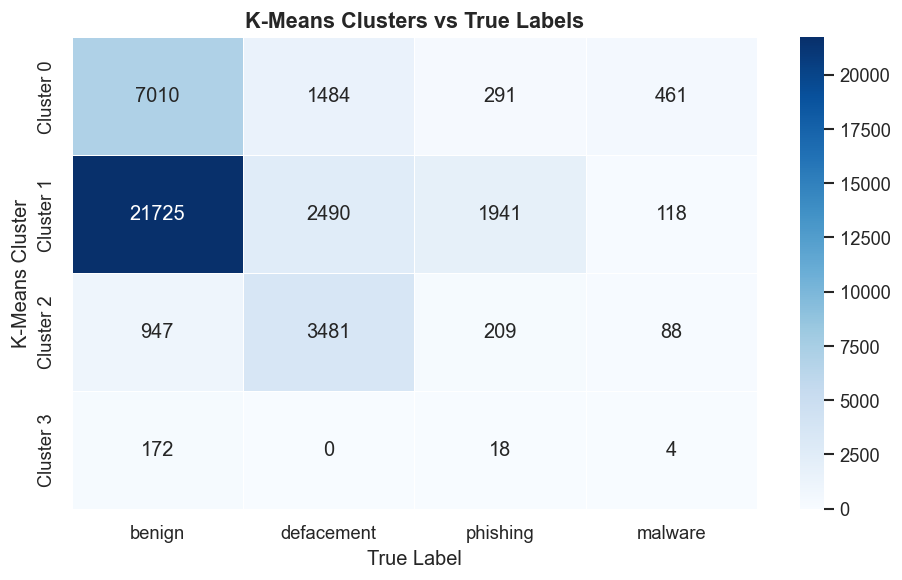

In [8]:
# Compare K-Means clusters vs true labels

# Crosstab: cluster assignment vs true label
comparison = pd.crosstab(
    cluster_labels,
    y.values,
    rownames=["Cluster"],
    colnames=["True Label"]
)
comparison.columns = [LABEL_MAP[i] for i in comparison.columns]
comparison.index   = [f"Cluster {i}" for i in comparison.index]

print("=== K-Means Cluster vs True Label Distribution ===")
print(comparison.to_string())

# Dominant class per cluster
print("\nDominant class per cluster")
for cluster in comparison.index:
    dominant = comparison.loc[cluster].idxmax()
    total    = comparison.loc[cluster].sum()
    count    = comparison.loc[cluster].max()
    print(f"  {cluster} → mostly {dominant} ({count}/{total}, {count/total:.1%})")

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(comparison, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("K-Means Clusters vs True Labels", fontsize=13, fontweight="bold")
plt.ylabel("K-Means Cluster")
plt.xlabel("True Label")
plt.tight_layout()
plt.show()

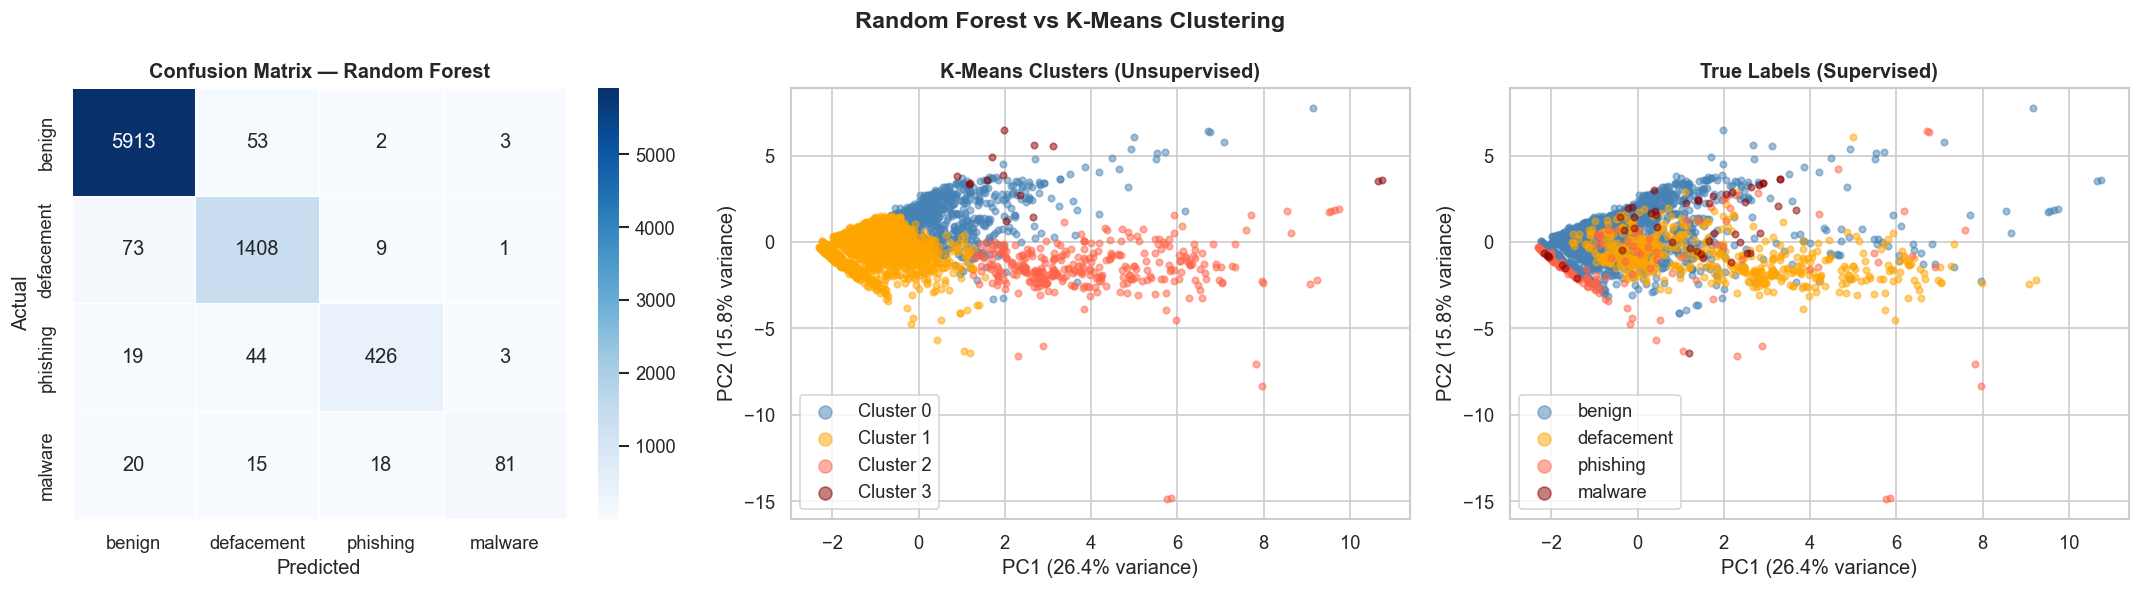

In [9]:
# CELL 8: Confusion Matrix (Random Forest) and PCA Cluster Visualization
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Confusion Matrix RF
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(LABEL_MAP.values()),
            yticklabels=list(LABEL_MAP.values()),
            ax=axes[0], linewidths=0.5)
axes[0].set_title("Confusion Matrix — Random Forest", fontweight="bold")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Plot 2 & 3: PCA visualization of K-Means clusters and true labels
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

# randomly sample 3000 points for clearer visualization
idx = np.random.choice(len(X_pca), size=3000, replace=False)

# Plot 2: K-Means clusters
cluster_colors = ["steelblue", "orange", "tomato", "darkred"]
for cluster_id in range(4):
    mask = cluster_labels[idx] == cluster_id
    axes[1].scatter(
        X_pca[idx][mask, 0], X_pca[idx][mask, 1],
        c=cluster_colors[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.5, s=15
    )
axes[1].set_title("K-Means Clusters (Unsupervised)", fontweight="bold")
axes[1].set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
axes[1].legend(markerscale=2)

# Plot 3: True labels
TYPE_COLORS = {
    "benign": "steelblue", "defacement": "orange",
    "phishing": "tomato",  "malware": "darkred"
}
true_labels_arr = y.values
for i, url_type in enumerate(["benign", "defacement", "phishing", "malware"]):
    mask = true_labels_arr[idx] == i
    axes[2].scatter(
        X_pca[idx][mask, 0], X_pca[idx][mask, 1],
        c=TYPE_COLORS[url_type],
        label=url_type, alpha=0.5, s=15
    )
axes[2].set_title("True Labels (Supervised)", fontweight="bold")
axes[2].set_xlabel(f"PC1 ({explained[0]:.1%} variance)")
axes[2].set_ylabel(f"PC2 ({explained[1]:.1%} variance)")
axes[2].legend(markerscale=2)

plt.suptitle("Random Forest vs K-Means Clustering",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

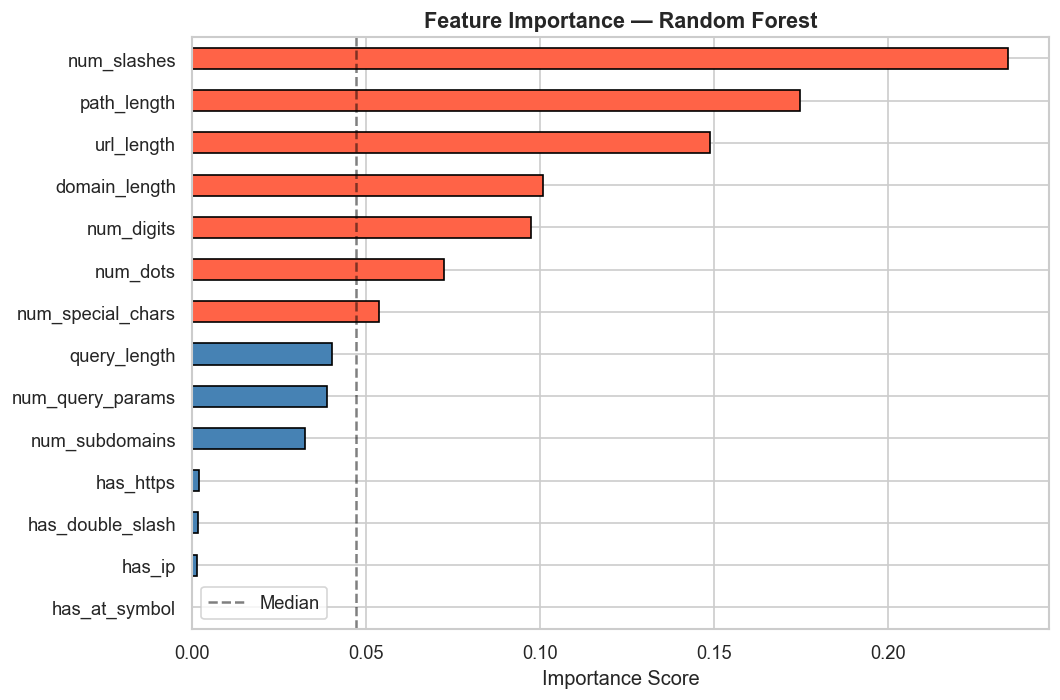

Top 5 Most Important Features
num_slashes      0.2346
path_length      0.1747
url_length       0.1489
domain_length    0.1010
num_digits       0.0975
dtype: float64


In [13]:
# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values()

plt.figure(figsize=(9, 6))
colors = ["tomato" if v > feat_imp.median()
          else "steelblue" for v in feat_imp]
feat_imp.plot(kind="barh", color=colors, edgecolor="black")
plt.title("Feature Importance — Random Forest",
          fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.axvline(feat_imp.median(), color="black",
            linestyle="--", alpha=0.5, label="Median")
plt.legend()
plt.tight_layout()
plt.show()

print("Top 5 Most Important Features")
print(feat_imp.sort_values(ascending=False).head(5).round(4))

In [ ]:
# CELL 10: Cross Validation & Save model
print("5-Fold Cross Validation\n")

scores = cross_val_score(rf_model, X, y, cv=5,
                         scoring="f1_weighted", n_jobs=-1)
print(f"Random Forest:")
print(f"  F1 per fold : {scores.round(4)}")
print(f"  Mean F1     : {scores.mean():.4f}")
print(f"  Std         : {scores.std():.4f}")

# Save
os.makedirs("../../models", exist_ok=True)

with open("../../models/url_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("../../models/url_feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("\nSaved:")
print(" models/url_model.pkl")
print(" models/url_feature_cols.pkl")

# Random Forest is used for prediction in the pipeline.
# K-Means and DBSCAN are used for exploratory analysis only
# and do not require saving.

5-Fold Cross Validation

Random Forest:
  F1 per fold : [0.9673 0.9651 0.9628 0.9684 0.9669]
  Mean F1     : 0.9661
  Std         : 0.0020

Saved:
 models/url_model.pkl
 models/url_feature_cols.pkl
